Image Dimensions: (629, 469)


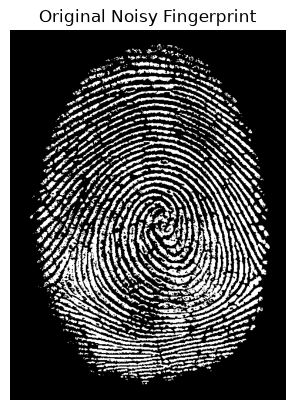

Structuring Element:
[[1 1 1]
 [1 1 1]
 [1 1 1]]


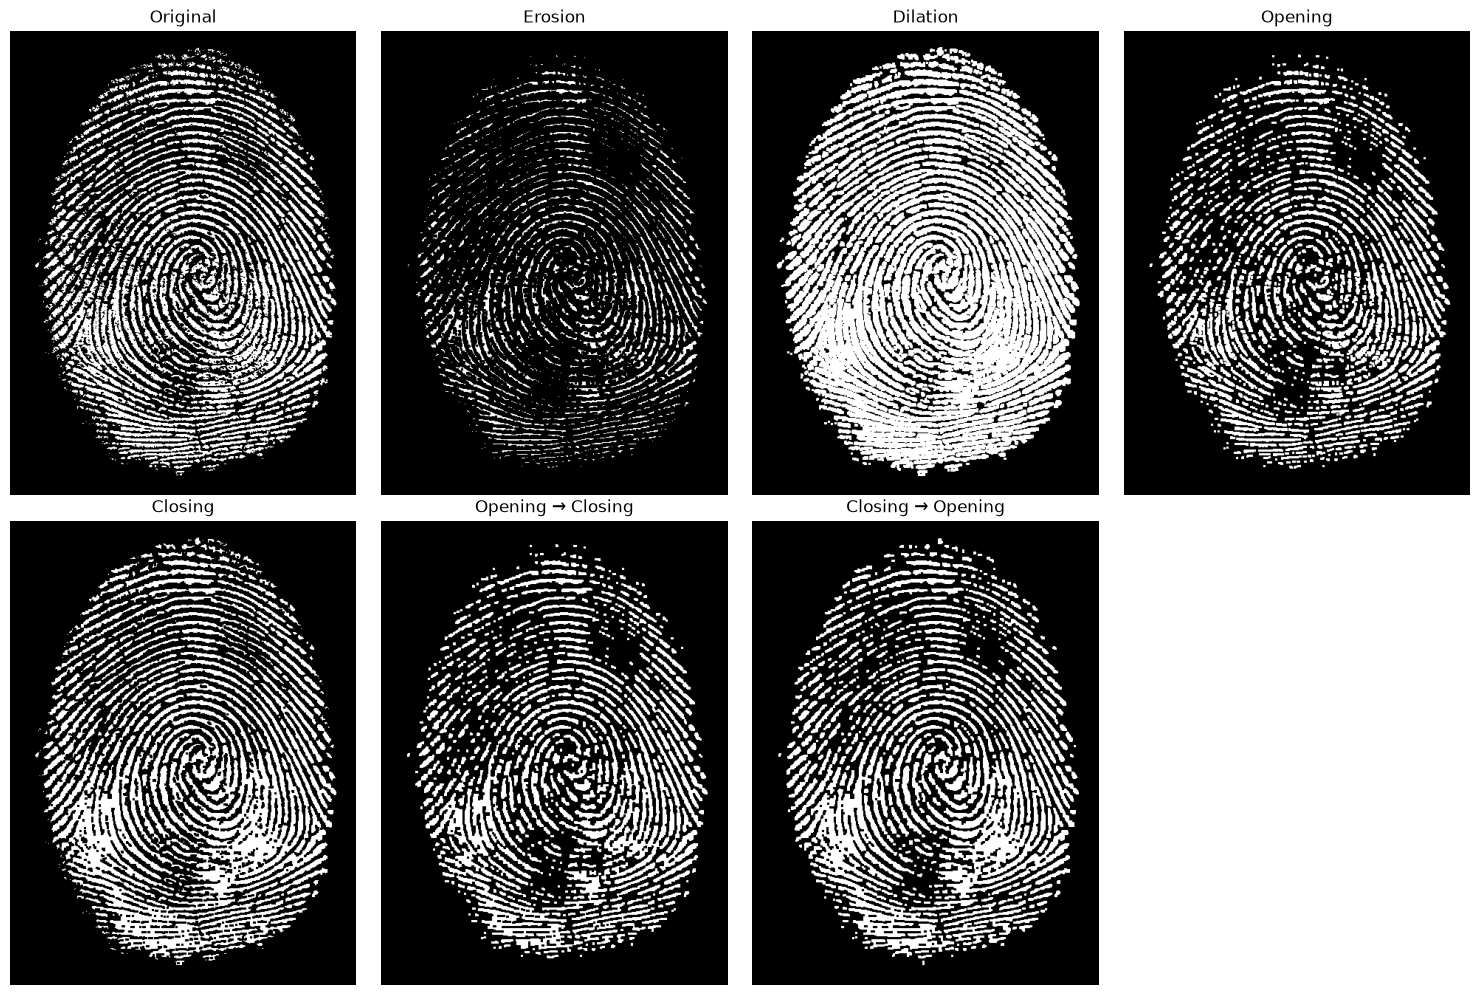

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("../images/fingerprint.jpg", cv2.IMREAD_GRAYSCALE)

_, binary = cv2.threshold(
    image,
    127,
    255,
    cv2.THRESH_BINARY
)

print("Image Dimensions:", binary.shape)

plt.imshow(binary, cmap="gray")
plt.title("Original Noisy Fingerprint")
plt.axis("off")
plt.show()

kernel = np.ones((3, 3), np.uint8)

print("Structuring Element:")
print(kernel)

erosion = cv2.erode(
    binary,
    kernel,
    iterations=1
)

cv2.imwrite(
    "../images/fingerprint_erosion.png",
    erosion
)

dilation = cv2.dilate(
    binary,
    kernel,
    iterations=1
)

cv2.imwrite(
    "../images/fingerprint_dilation.png",
    dilation
)

opening = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    kernel
)

closing = cv2.morphologyEx(
    binary,
    cv2.MORPH_CLOSE,
    kernel
)

cv2.imwrite(
    "../images/fingerprint_opening.png",
    opening
)

cv2.imwrite(
    "../images/fingerprint_closing.png",
    closing
)

opening_closing = cv2.morphologyEx(
    opening,
    cv2.MORPH_CLOSE,
    kernel
)

cv2.imwrite(
    "../images/fingerprint_opening_closing.png",
    opening_closing
)

closing_opening = cv2.morphologyEx(
    closing,
    cv2.MORPH_OPEN,
    kernel
)

cv2.imwrite(
    "../images/fingerprint_closing_opening.png",
    closing_opening
)

plt.figure(figsize=(15, 10))

plt.subplot(2, 4, 1)
plt.imshow(binary, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(2, 4, 2)
plt.imshow(erosion, cmap="gray")
plt.title("Erosion")
plt.axis("off")

plt.subplot(2, 4, 3)
plt.imshow(dilation, cmap="gray")
plt.title("Dilation")
plt.axis("off")

plt.subplot(2, 4, 4)
plt.imshow(opening, cmap="gray")
plt.title("Opening")
plt.axis("off")

plt.subplot(2, 4, 5)
plt.imshow(closing, cmap="gray")
plt.title("Closing")
plt.axis("off")

plt.subplot(2, 4, 6)
plt.imshow(opening_closing, cmap="gray")
plt.title("Opening → Closing")
plt.axis("off")

plt.subplot(2, 4, 7)
plt.imshow(closing_opening, cmap="gray")
plt.title("Closing → Opening")
plt.axis("off")

plt.tight_layout()
plt.show()